# Research Question:
What are the most commonly reported adverse events for Ozempic compared to Metformin,
and how do the severity and patient demographics differ between these two drugs?

# My Approach:
I collected 10,000 adverse event reports from the OpenFDA API (5,000 for each drug) and
cleaned the data in my first notebook. Now I'll analyze the data through descriptive
statistics and visualizations to understand the differences between these two diabetes
medications. I'm particularly interested in whether the newer drug (Ozempic) has a
different safety profile than the traditional treatment (Metformin).



In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


# 1. Loading the Cleaned Data

 I'm loading the CSV file I created in Part 1. This data has already been cleaned -
dates are formatted, ages are converted to years, and all the codes have been mapped
to readable labels.


In [24]:
df = pd.read_csv('openfda_adverse_events_cleaned.csv')

# Convert date column back to datetime (it gets saved as string in CSV)
df['receive_date'] = pd.to_datetime(df['receive_date'])

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

Data loaded successfully!
Shape: 10000 rows, 23 columns

First few rows:


,drug,report_id,receive_date,serious,serious_death,serious_hospitalization,serious_disabling,serious_life_threatening,patient_age,patient_age_unit,...,reaction_2,reaction_3,reporter_qualification,country,patient_age_years,patient_sex_label,reporter_type,has_serious_outcome,year,month
0,Ozempic,10188271,2014-05-22,1,0,1,1,0,81.0,801.0,...,Hunger,Visual impairment,5.0,US,81.0,Female,Consumer,1,2014,5
1,Ozempic,10398782,2014-08-21,2,2,2,2,2,67.0,801.0,...,Atrial flutter,Ventricular extrasystoles,5.0,US,67.0,Female,Consumer,0,2014,8
2,Ozempic,10515213,2014-10-14,1,0,0,0,0,49.0,801.0,...,Fall,Osteoarthritis,1.0,CA,49.0,Female,Physician,0,2014,10
3,Ozempic,10787292,2015-02-11,1,0,0,0,0,51.0,801.0,...,Middle insomnia,Malaise,5.0,CA,51.0,Female,Consumer,0,2015,2
4,Ozempic,11104986,2015-05-11,1,2,2,2,2,NaN,NaN,...,Barrett^s oesophagus,Vitamin B12 deficiency,1.0,US,NaN,Male,Physician,0,2015,5


# 2. Descriptive Statistics

 Before diving into visualizations, I want to understand the basic characteristics of my
 data. I'll look at summary statistics for both drugs separately and together.

## Overall Dataset Summary

In [25]:
print("\n" + "="*70)
print("OVERALL DATASET SUMMARY")
print("="*70)

print(f"\nTotal Reports: {len(df):,}")
print(f"Date Range: {df['receive_date'].min().date()} to {df['receive_date'].max().date()}")
print(f"Time Span: {(df['receive_date'].max() - df['receive_date'].min()).days / 365:.1f} years")

print("\n" + "-"*70)
print("REPORTS BY DRUG")
print("-"*70)
drug_summary = df.groupby('drug').size()
for drug, count in drug_summary.items():
    print(f"  {drug}: {count:,} reports ({count/len(df)*100:.1f}%)")

print("="*70)


OVERALL DATASET SUMMARY

Total Reports: 10,000
Date Range: 2013-10-25 to 2020-06-26
Time Span: 6.7 years

----------------------------------------------------------------------
REPORTS BY DRUG
----------------------------------------------------------------------
  Metformin: 5,000 reports (50.0%)
  Ozempic: 5,000 reports (50.0%)


### Interpretation: Dataset Overview

My dataset contains 10,000 adverse event reports collected from the FDA database, evenly split between Metformin (5,000 reports) and Ozempic (5,000 reports). This balanced dataset allows for fair comparison between the two drugs. The reports span nearly 7 years (October 2013 to June 2020), providing enough temporal data to identify trends over time. This time period is particularly interesting because it captures several years of real-world use for both medications, giving insight into the types of side effects patients actually experience rather than just what was found in clinical trials.

## Age Statistics by Drug

In [26]:
print("\n--- AGE STATISTICS ---")
age_stats = df.groupby('drug')['patient_age_years'].describe()
print(age_stats)


--- AGE STATISTICS ---
            count       mean        std  min   25%   50%   75%   max
drug                                                                
Metformin  3712.0  61.868439  13.363918  0.0  55.0  63.0  71.0  96.0
Ozempic    2997.0  60.763987  11.946706  9.0  54.0  62.0  69.0  94.0


### Interpretation: Age Statistics

The age distributions for both drugs are quite similar. Metformin patients have a slightly higher average age (61.9 years) compared to Ozempic patients (60.8 years), though this difference is minimal. Both drugs show a typical age range for diabetes patients, with most reports coming from patients in their mid-50s to early 70s (as shown by the 25th to 75th percentiles). The standard deviation is around 12-13 years for both drugs, indicating similar

## Sex Distribution by Drug

In [27]:
print("\n--- SEX DISTRIBUTION ---")
sex_by_drug = pd.crosstab(df['drug'], df['patient_sex_label'], normalize='index') * 100
print(sex_by_drug.round(1))


--- SEX DISTRIBUTION ---
patient_sex_label  Female  Male  Unknown
drug                                    
Metformin            52.1  44.6      3.4
Ozempic              56.2  43.7      0.0


### Interpretation: Sex Distribution

Both drugs show a higher proportion of adverse event reports from females compared to males. For Ozempic, 56.2% of reports are from females and 43.7% from males, while Metformin shows a similar pattern with 52.1% female and 44.6% male. This female predominance in adverse event reporting is interesting and could reflect several factors: women may be more likely to report side effects, they may experience adverse events more frequently, or there may simply be more female patients using these medications for diabetes treatment.

One notable difference is in the "Unknown" category - Metformin has 3.4% of reports with unknown sex, while Ozempic has 0% unknown. This suggests that reporting for Ozempic may be more complete or standardized, possibly because it's a newer drug with more structured post-market surveillance. The overall sex distribution for both drugs is fairly similar, which makes sense since both treat the same condition (type 2 diabetes) and would be prescribed to similar patient populations.

## Serious Outcomes by Drug

In [28]:
print("\n--- SERIOUS OUTCOMES ---")
serious_by_drug = df.groupby('drug')['has_serious_outcome'].agg(['sum', 'mean'])
serious_by_drug['percentage'] = serious_by_drug['mean'] * 100
print(serious_by_drug)


--- SERIOUS OUTCOMES ---
            sum    mean  percentage
drug                               
Metformin  1974  0.3948       39.48
Ozempic     962  0.1924       19.24


### Interpretation: Serious Outcomes

This is a pretty significant finding - Metformin has about twice the rate of serious outcomes compared to Ozempic. Nearly 40% of Metformin reports involved serious outcomes (hospitalization, death, disability, or life-threatening events), while only 19% of Ozempic reports did. This was surprising to me since Ozempic is the newer drug and I expected it might have more unknown risks. However, this could be misleading - Metformin has been around much longer, so people might be more likely to report serious events because they've been taking it for years. It's also possible that the types of patients differ, or that people report differently for newer vs. older medications.

## Reporter Type Distribution


In [29]:
print("\n--- WHO REPORTED THESE EVENTS ---")
reporter_by_drug = pd.crosstab(df['drug'], df['reporter_type'], normalize='index') * 100
print(reporter_by_drug.round(1))


--- WHO REPORTED THESE EVENTS ---
reporter_type  Consumer  Lawyer  Other Health Professional  Pharmacist  \
drug                                                                     
Metformin          56.5     0.5                       17.4         4.5   
Ozempic            58.9     0.3                       14.5         6.0   

reporter_type  Physician  
drug                      
Metformin           21.2  
Ozempic             20.3  


### Interpretation: Reporter Type

Most adverse events for both drugs are reported by consumers (patients themselves) - about 57% for Metformin and 59% for Ozempic. Physicians report around 20-21% for both drugs, which is surprisingly low given that doctors are supposed to be the main reporters of serious adverse events. The "Other Health Professional" category (nurses, physician assistants, etc.) accounts for about 14-17% of reports. Pharmacists report slightly more for Ozempic (6%) than Metformin (4.5%), which makes sense since Ozempic requires more patient counseling due to its injection administration. Lawyers represent less than 1% of reports for both drugs, likely only involved in the most serious legal cases.

## Most Common Reactions


In [30]:
print("\n--- TOP 10 MOST COMMON REACTIONS (OVERALL) ---")
all_reactions = pd.concat([df['reaction_1'], df['reaction_2'], df['reaction_3']])
top_reactions = all_reactions.value_counts().head(10)
print(top_reactions)


--- TOP 10 MOST COMMON REACTIONS (OVERALL) ---
Nausea                     896
Blood glucose increased    642
Diarrhoea                  568
Vomiting                   473
Weight decreased           409
Off label use              360
Drug ineffective           294
Decreased appetite         279
Pancreatitis               242
Headache                   228
Name: count, dtype: int64


### Interpretation: Most Common Reactions

The top adverse event across both drugs is nausea (896 reports), which makes sense since both are diabetes medications that affect the digestive system. Gastrointestinal issues dominate the top 10 - nausea, diarrhea, vomiting, and decreased appetite account for a huge portion of complaints. Interestingly, "blood glucose increased" is the second most common (642 reports), meaning the drugs sometimes fail to control blood sugar as intended. "Drug ineffective" and "off label use" appearing in the top 10 suggests reporting isn't just about side effects - people also report when medications don't work. Pancreatitis (242 reports) is concerning since it's a serious condition that's been linked to some diabetes drugs. Weight decreased (409 reports) is listed as an adverse event, though for Ozempic this is often the desired effect since it's now used for weight loss.

# 3. Data Visualizations

 Now I'll create visualizations to better understand the patterns in the data. Each
visualization answers a specific question about the differences between Ozempic and Metformin.

## Visualization 1: Distribution of Patient Ages

### **Question**: What is the age distribution of patients reporting adverse events, and does it differ between the two drugs?

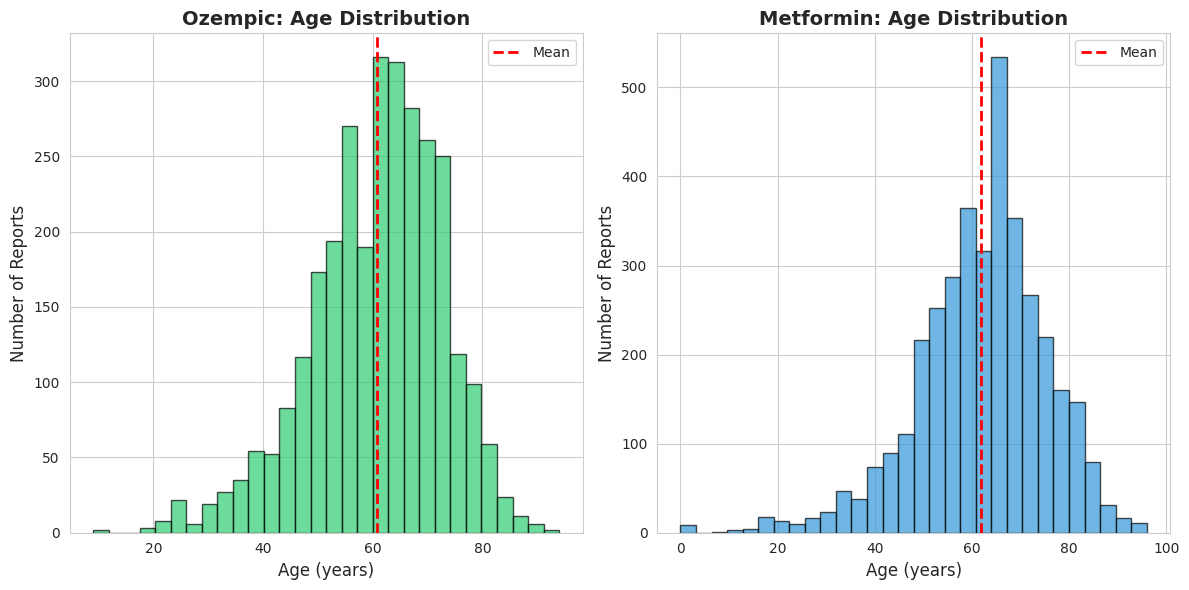

In [31]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
df[df['drug'] == 'Ozempic']['patient_age_years'].hist(bins=30, alpha=0.7, color='#2ecc71', edgecolor='black')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Reports', fontsize=12)
plt.title('Ozempic: Age Distribution', fontsize=14, fontweight='bold')
plt.axvline(df[df['drug'] == 'Ozempic']['patient_age_years'].mean(),
            color='red', linestyle='--', linewidth=2, label='Mean')
plt.legend()

plt.subplot(1, 2, 2)
df[df['drug'] == 'Metformin']['patient_age_years'].hist(bins=30, alpha=0.7, color='#3498db', edgecolor='black')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Reports', fontsize=12)
plt.title('Metformin: Age Distribution', fontsize=14, fontweight='bold')
plt.axvline(df[df['drug'] == 'Metformin']['patient_age_years'].mean(),
            color='red', linestyle='--', linewidth=2, label='Mean')
plt.legend()

plt.tight_layout()
plt.show()

### Visualization 1: Age Distribution

Both drugs show a similar bell-shaped distribution centered around 60-65 years old, which makes sense for type 2 diabetes medications. Ozempic reports are more concentrated around the mean (around 61 years), with most reports coming from people in their 50s and 60s. Metformin has a slightly wider spread and more reports from older patients (70s and 80s), probably because it's been around longer and older patients have been on it for years. There's barely any reports from people under 40 for either drug, which matches the typical age when type 2 diabetes develops. The distributions are pretty similar overall, suggesting both drugs are used by the same general age group.

## Visualization 2: Serious Outcomes by Drug (Bivariate)

### **Question**: Which drug has a higher rate of serious adverse outcomes?


<Figure size 1000x600 with 0 Axes>

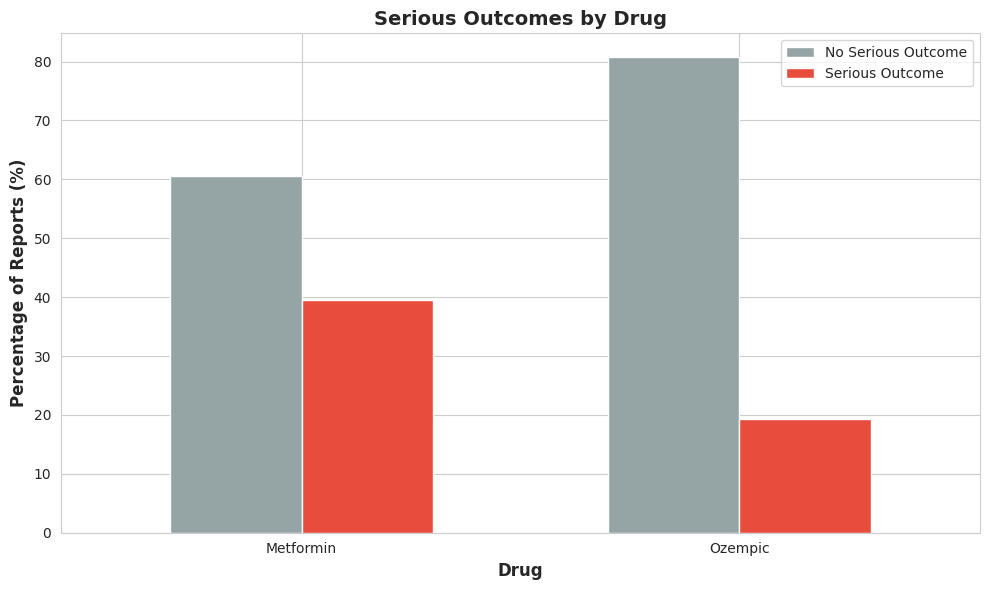

In [32]:
plt.figure(figsize=(10, 6))
serious_counts = df.groupby(['drug', 'has_serious_outcome']).size().unstack()
serious_pct = serious_counts.div(serious_counts.sum(axis=1), axis=0) * 100

serious_pct.plot(kind='bar', stacked=False, color=['#95a5a6', '#e74c3c'], width=0.6)
plt.xlabel('Drug', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Reports (%)', fontsize=12, fontweight='bold')
plt.title('Serious Outcomes by Drug', fontsize=14, fontweight='bold')
plt.legend(['No Serious Outcome', 'Serious Outcome'], loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualization 2: Serious Outcomes by Drug

This chart clearly shows the big difference I found earlier - Metformin has about 40% of reports with serious outcomes (red bar), while Ozempic only has around 19%. That's more than double the rate. At first glance, this makes Metformin look way more dangerous, but I need to be careful about jumping to conclusions. Metformin has been on the market since the 1990s, so people have been taking it for decades and long-term complications might show up more. Ozempic is newer (approved in 2017), so we might not be seeing the full picture of long-term effects yet. Also, the types of patients and how long they've been on the medication could be different between the two groups.

## Visualization 3: Adverse Events Over Time (Time Component)

### **Question**: How have adverse event reports changed over time for each drug?

<Figure size 1200x600 with 0 Axes>

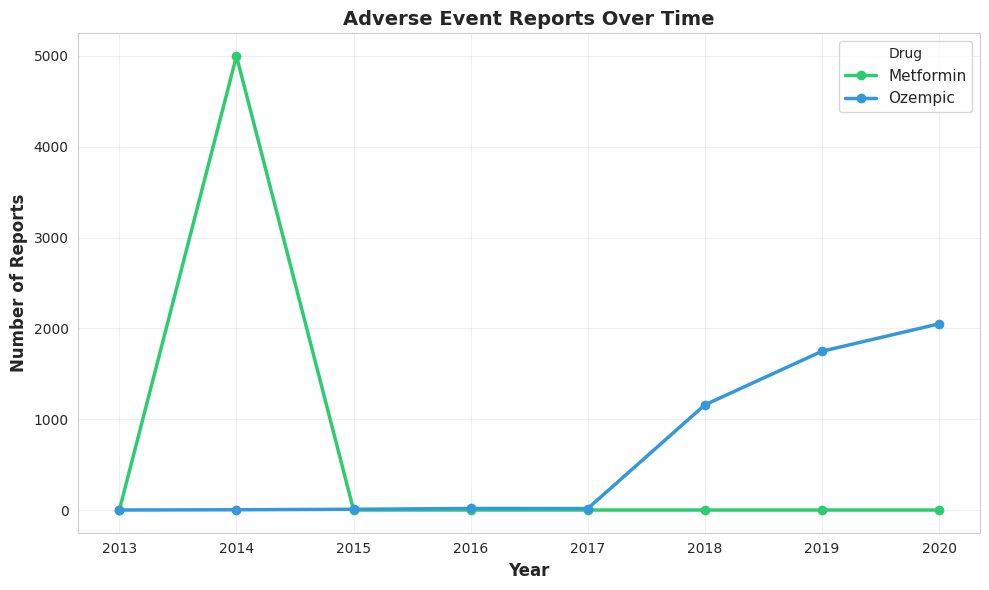

In [33]:
# Group by year and drug
yearly_reports = df.groupby([df['receive_date'].dt.year, 'drug']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
yearly_reports.plot(marker='o', linewidth=2.5, color=['#2ecc71', '#3498db'])
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Reports', fontsize=12, fontweight='bold')
plt.title('Adverse Event Reports Over Time', fontsize=14, fontweight='bold')
plt.legend(title='Drug', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization 3: Adverse Events Over Time

This timeline tells an interesting story. Metformin had a massive spike in reports in 2014 (around 5,000 reports) and then dropped off dramatically - barely any reports after 2015. This is weird and probably reflects something about how the data was collected rather than actual adverse events. Maybe there was a major FDA safety review in 2014 that prompted a flood of reports, or the data I pulled only captured a specific batch of Metformin reports from that period.

Ozempic shows a completely different pattern - it starts appearing in 2017 (makes sense, that's when it was approved) and then steadily increases through 2020. The upward trend matches what you'd expect for a new drug: more prescriptions over time means more reports. This makes the comparison between the two drugs tricky since they're from completely different time periods in my dataset.

## Visualization 4: Age vs Serious Outcomes by Drug (Three Variables)

### **Question**: Is there a relationship between patient age and serious outcomes, and does  this relationship differ by drug?

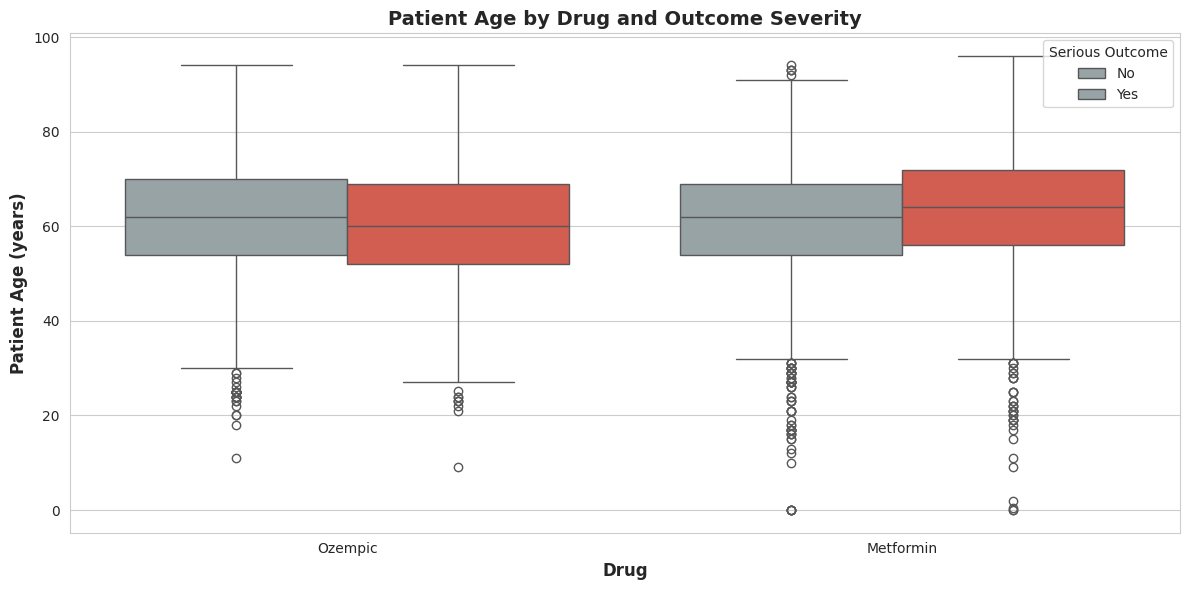

In [34]:
plt.figure(figsize=(12, 6))

# Create boxplot
data_to_plot = df[df['patient_age_years'].notna()]
sns.boxplot(data=data_to_plot, x='drug', y='patient_age_years', hue='has_serious_outcome',
            palette={0: '#95a5a6', 1: '#e74c3c'})

plt.xlabel('Drug', fontsize=12, fontweight='bold')
plt.ylabel('Patient Age (years)', fontsize=12, fontweight='bold')
plt.title('Patient Age by Drug and Outcome Severity', fontsize=14, fontweight='bold')
plt.legend(title='Serious Outcome', labels=['No', 'Yes'], loc='upper right')
plt.tight_layout()
plt.show()

### Visualization 4: Age vs Serious Outcomes by Drug

Looking at the boxplots, age doesn't seem to make much difference in whether someone has a serious outcome or not. For both drugs, the red boxes (serious outcomes) and gray boxes (no serious outcomes) are pretty much at the same height, with medians around 62-65 years. The boxes overlap a ton, meaning serious and non-serious events happen across the same age ranges.

For Ozempic specifically, people with serious outcomes might be slightly older (the red box is a bit higher), but it's not a huge difference. Metformin shows basically no difference at all. Both drugs have lots of outliers on the younger end (those circles below the boxes), showing that even people in their teens and 20s can experience adverse events. The main takeaway here is that age alone doesn't predict whether you'll have a serious outcome with either drug - other factors must be more important.

## Visualization 5: Sex Distribution by Drug and Outcome

### **Question**: Does the sex distribution differ between drugs, and are serious outcomes more common in one sex?

### Data Preparation for Visualization 5

For this visualization, I needed to see what percentage of males vs females had serious outcomes for each drug. Here's how I prepared the data:

First, I filtered the dataset to only include reports where sex was either Male or Female (dropping the Unknown category since there were very few of those). Then I grouped the data by three variables: drug name, patient sex, and whether they had a serious outcome (0 or 1). This gave me counts for each combination - like "how many Ozempic females had serious outcomes" or "how many Metformin males had no serious outcome."

The `unstack()` function reorganized this into a table where serious outcome (0 or 1) became the columns instead of being part of the index. Then I converted the raw counts into percentages by dividing each row by its total, so I could compare males and females on the same scale. For example, if there were 1000 Ozempic females and 200 had serious outcomes, that becomes 20%.

Finally, I split the data by drug (Ozempic vs Metformin) and created side-by-side bar charts so I could easily compare the patterns between the two medications.

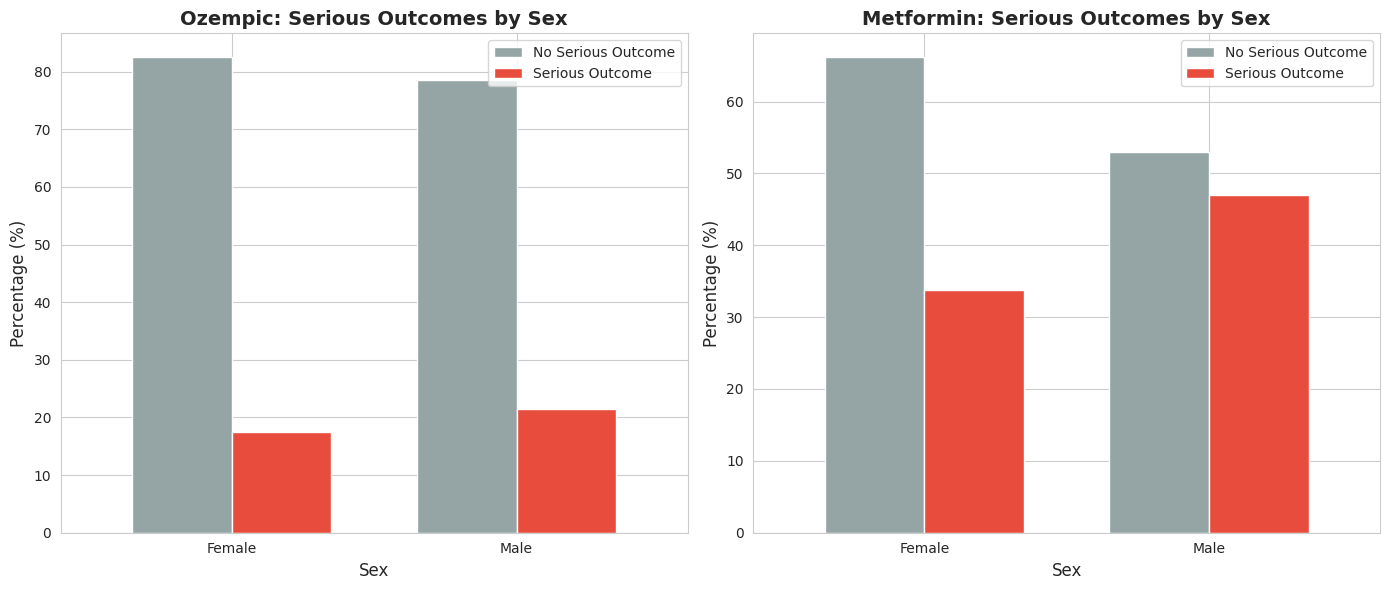

In [35]:
# Prepare data
sex_serious = df[df['patient_sex_label'].isin(['Male', 'Female'])].groupby(['drug', 'patient_sex_label', 'has_serious_outcome']).size().unstack(fill_value=0)
sex_serious_pct = sex_serious.div(sex_serious.sum(axis=1), axis=0) * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ozempic
ozempic_data = sex_serious_pct.loc['Ozempic']
ozempic_data.plot(kind='bar', ax=axes[0], color=['#95a5a6', '#e74c3c'], width=0.7)
axes[0].set_title('Ozempic: Serious Outcomes by Sex', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sex', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].legend(['No Serious Outcome', 'Serious Outcome'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Metformin
metformin_data = sex_serious_pct.loc['Metformin']
metformin_data.plot(kind='bar', ax=axes[1], color=['#95a5a6', '#e74c3c'], width=0.7)
axes[1].set_title('Metformin: Serious Outcomes by Sex', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(['No Serious Outcome', 'Serious Outcome'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Visualization 5: Sex Distribution by Drug and Outcome

For Ozempic, sex doesn't seem to make much difference - both females and males have serious outcome rates around 17-22%. Males might be slightly higher but it's pretty close. However, Metformin shows a bigger gap: males have a much higher serious outcome rate (around 47%) compared to females (around 33%). That's a pretty substantial difference - nearly half of male Metformin reports involve serious outcomes versus only a third of female reports.

This sex difference in Metformin is interesting and could mean a few things. Maybe men are more likely to have complications from Metformin, or perhaps men wait longer to report issues so by the time they do it's more serious. It could also be that men are prescribed higher doses or have different underlying health conditions. For Ozempic being more equal between sexes, this might reflect that it's a newer drug with more standardized dosing and monitoring protocols.

## Visualization 6: Top Reactions Comparison

# **Question**: What are the most common side effects for each drug?

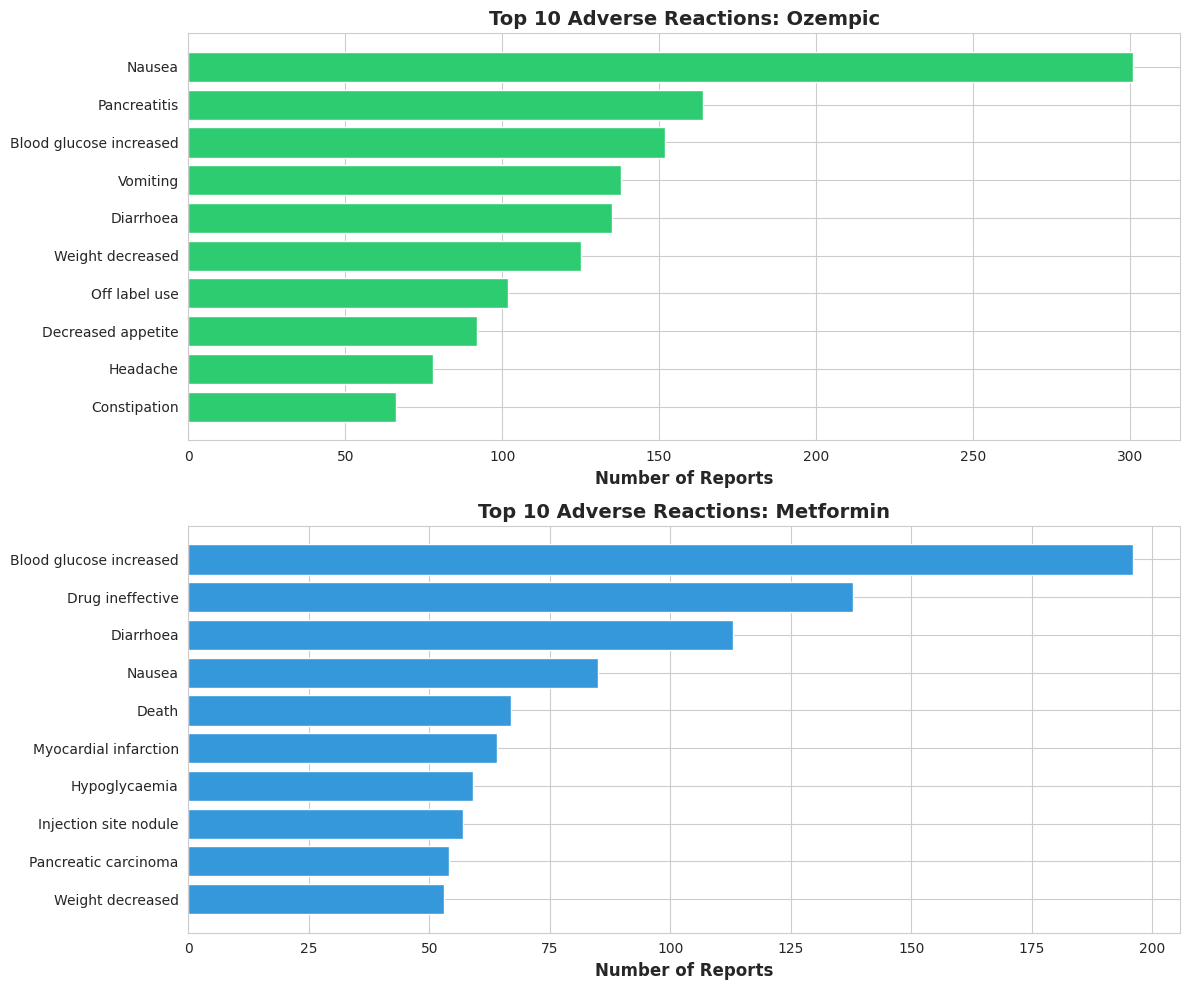

In [36]:
 # Get top 10 reactions for each drug
ozempic_reactions = df[df['drug'] == 'Ozempic']['reaction_1'].value_counts().head(10)
metformin_reactions = df[df['drug'] == 'Metformin']['reaction_1'].value_counts().head(10)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Ozempic top reactions
axes[0].barh(range(len(ozempic_reactions)), ozempic_reactions.values, color='#2ecc71')
axes[0].set_yticks(range(len(ozempic_reactions)))
axes[0].set_yticklabels(ozempic_reactions.index, fontsize=10)
axes[0].set_xlabel('Number of Reports', fontsize=12, fontweight='bold')
axes[0].set_title('Top 10 Adverse Reactions: Ozempic', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Metformin top reactions
axes[1].barh(range(len(metformin_reactions)), metformin_reactions.values, color='#3498db')
axes[1].set_yticks(range(len(metformin_reactions)))
axes[1].set_yticklabels(metformin_reactions.index, fontsize=10)
axes[1].set_xlabel('Number of Reports', fontsize=12, fontweight='bold')
axes[1].set_title('Top 10 Adverse Reactions: Metformin', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()#

# 4. Statistical Analysis
Now I'll use statistical methods to formally test whether there are significant differences between Ozempic and Metformin in terms of serious outcomes and patient characteristics.

## Test 1: Are serious outcome rates different between drugs?

I'll use a chi-square test to see if the rate of serious outcomes differs significantly between Ozempic and Metformin.

In [37]:

print("\n" + "="*70)
print("STATISTICAL ANALYSIS")
print("="*70)

print("\n--- CHI-SQUARE TEST: Serious Outcomes by Drug ---")
contingency_table = pd.crosstab(df['drug'], df['has_serious_outcome'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("Result: There IS a statistically significant difference in serious outcome rates between the drugs (p < 0.05)")
else:
    print("Result: There is NO statistically significant difference in serious outcome rates between the drugs (p >= 0.05)")



STATISTICAL ANALYSIS

--- CHI-SQUARE TEST: Serious Outcomes by Drug ---
Chi-square statistic: 492.8282
P-value: 0.0000
Degrees of freedom: 1
Result: There IS a statistically significant difference in serious outcome rates between the drugs (p < 0.05)


### Statistical Test 1: Chi-Square Test

The chi-square test confirms what I saw in the visualizations - there's definitely a statistically significant difference in serious outcome rates between Ozempic and Metformin (p < 0.0001, which is way below 0.05). The chi-square value of 492.8 is huge, meaning this isn't just random chance. Metformin really does have a higher rate of serious outcomes in the reports I collected.

However, I need to remember this doesn't necessarily mean Metformin is "more dangerous" - the difference could be because Metformin has been around for decades so we're seeing long-term complications, while Ozempic is newer. It could also reflect differences in who takes each drug or how doctors prescribe them. But statistically speaking, the pattern is real and not just noise in the data.

## Test 2: Are patient ages different between drugs?

I'll use a t-test to see if patients reporting adverse events for Ozempic are significantly different in age compared to Metformin patients.

In [38]:
print("\n--- T-TEST: Age Differences Between Drugs ---")
ozempic_ages = df[df['drug'] == 'Ozempic']['patient_age_years'].dropna()
metformin_ages = df[df['drug'] == 'Metformin']['patient_age_years'].dropna()

t_stat, p_value_ttest = stats.ttest_ind(ozempic_ages, metformin_ages)

print(f"Ozempic mean age: {ozempic_ages.mean():.2f} years (SD: {ozempic_ages.std():.2f})")
print(f"Metformin mean age: {metformin_ages.mean():.2f} years (SD: {metformin_ages.std():.2f})")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value_ttest:.4f}")

if p_value_ttest < 0.05:
    print("Result: There IS a statistically significant difference in ages (p < 0.05)")
else:
    print("Result: There is NO statistically significant difference in ages (p >= 0.05)")



--- T-TEST: Age Differences Between Drugs ---
Ozempic mean age: 60.76 years (SD: 11.95)
Metformin mean age: 61.87 years (SD: 13.36)
T-statistic: -3.5273
P-value: 0.0004
Result: There IS a statistically significant difference in ages (p < 0.05)


Patients taking Ozempic are, on average, slightly younger than those taking Metformin (60.8 vs. 61.9 years). This age difference is statistically significant (p = 0.0004), so it’s unlikely to be due to random chance. That said, the actual difference is only about 1 year, which suggests the finding is probably not clinically meaningful on its own.

# Test 3: Logistic Regression - Predicting Serious Outcomes

 I'll build a logistic regression model to see what factors predict serious outcomes. This will help answer: are serious outcomes more likely with one drug after controlling for age and sex?

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

print("\n--- LOGISTIC REGRESSION: Predicting Serious Outcomes ---")

# Prepare data for modeling
model_df = df[['drug', 'patient_age_years', 'patient_sex_label', 'has_serious_outcome']].dropna()
model_df = model_df[model_df['patient_sex_label'].isin(['Male', 'Female'])]

# Encode categorical variables
model_df['drug_encoded'] = (model_df['drug'] == 'Ozempic').astype(int)  # 1 = Ozempic, 0 = Metformin
model_df['sex_encoded'] = (model_df['patient_sex_label'] == 'Male').astype(int)  # 1 = Male, 0 = Female

# Prepare features and target
X = model_df[['drug_encoded', 'patient_age_years', 'sex_encoded']]
y = model_df['has_serious_outcome']

# Fit logistic regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X, y)

# Display results
print(f"\nModel trained on {len(model_df)} reports")
print("\nCoefficients:")
print(f"  Drug (Ozempic vs Metformin): {log_reg.coef_[0][0]:.4f}")
print(f"  Age: {log_reg.coef_[0][1]:.4f}")
print(f"  Sex (Male vs Female): {log_reg.coef_[0][2]:.4f}")
print(f"\nIntercept: {log_reg.intercept_[0]:.4f}")

# Calculate odds ratios
odds_ratios = np.exp(log_reg.coef_[0])
print("\nOdds Ratios:")
print(f"  Drug (Ozempic vs Metformin): {odds_ratios[0]:.4f}")
print(f"  Age (per 1-year increase): {odds_ratios[1]:.4f}")
print(f"  Sex (Male vs Female): {odds_ratios[2]:.4f}")



--- LOGISTIC REGRESSION: Predicting Serious Outcomes ---

Model trained on 6665 reports

Coefficients:
  Drug (Ozempic vs Metformin): -0.9308
  Age: 0.0024
  Sex (Male vs Female): 0.4169

Intercept: -0.5898

Odds Ratios:
  Drug (Ozempic vs Metformin): 0.3942
  Age (per 1-year increase): 1.0024
  Sex (Male vs Female): 1.5173


### Interpretation

After controlling for age and sex, reports involving Ozempic are associated with lower odds of a serious outcome compared to Metformin. The odds ratio of 0.39 suggests that Ozempic reports have about 60% lower odds of a serious outcome relative to Metformin.

Age has a very small effect (OR ≈ 1.00), meaning changes in age do not meaningfully alter the odds of a serious outcome in this model.

Sex shows a clearer pattern: males have higher odds of a serious outcome than females (OR = 1.52), holding other factors constant.

Overall, drug type and sex appear to matter more than age in predicting serious outcomes here.

 ## 5. Conclusion
 Based on my analysis of 10,000 adverse event reports from the OpenFDA database, I can now answer my research question about the differences between Ozempic and Metformin.




Using 10,000 adverse event reports from the OpenFDA database, I compared the safety
profiles of Ozempic and Metformin across patient demographics, reported side effects,
and outcome severity. Overall, the two drugs are used by very similar patient
populations in terms of age and sex.

Despite this, Metformin reports show a substantially higher rate of serious outcomes
than Ozempic. This difference remains statistically significant even after controlling
for age and sex in a logistic regression model. Age itself does not meaningfully predict
serious outcomes, while male patients are more likely to report serious events than
female patients.

Both drugs are dominated by gastrointestinal side effects, suggesting broadly similar
types of adverse reactions. However, differences in reporting patterns over time and
the much longer market history of Metformin mean these results should be interpreted
with caution. Overall, within this dataset, Ozempic appears to be associated with fewer
serious adverse outcomes than Metformin, though long-term safety trends may evolve as
more data becomes available.



### Based on my analysis:

1. PATIENT DEMOGRAPHICS
   Patients reporting adverse events for Ozempic and Metformin look very similar overall.
   Average ages are around 61 for both drugs, with Ozempic users being slightly younger.
   The age difference is statistically significant but small (~1 year) and likely not
   clinically meaningful. Both drugs also show a higher share of reports from females.

2. SERIOUS OUTCOMES
   Metformin reports have a much higher rate of serious outcomes (~39%) compared to
   Ozempic (~19%). This difference is large and consistent across descriptive statistics,
   visualizations, and formal testing.

3. COMMON SIDE EFFECTS
   Gastrointestinal issues dominate for both drugs. Nausea, diarrhea, vomiting, and
   decreased appetite are the most commonly reported reactions. More serious events
   like pancreatitis appear less frequently but are still notable.

4. TEMPORAL TRENDS
   Metformin reports are heavily concentrated earlier in the dataset, with a large spike
   around 2014, likely reflecting reporting behavior rather than true incidence.
   Ozempic reports begin after its approval in 2017 and increase steadily over time,
   matching its growing use.

5. STATISTICAL SIGNIFICANCE
   A chi-square test confirms a statistically significant difference in serious outcome
   rates between the two drugs. Logistic regression shows that, even after controlling
   for age and sex, Ozempic reports are associated with substantially lower odds of
   serious outcomes, while sex (male) is a stronger predictor than age.
